# Lid-Driven Cavity — PINN Solver
# Physics-Informed Neural Network for 2-D incompressible Navier-Stokes (Re = 100)

In [5]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

from pinn import PINN, ns_residual, make_boundary_data, make_collocation_points
from pinn import eval_all_losses, eval_flow_field, visualize

## Hyperparameters and Data

In [2]:
# Define Hyperparameters
N_b = 1_000  # boundary sample points
N_f = 10_000  # training collocation points
N_eval_pde = 2_000  # fresh points for eval L_pde (every 100 epochs)
nu = 0.01  # kinematic viscosity  →  Re = U*L/nu = 100
layers = [2, 64, 64, 64, 64, 3]

lr = 1e-3
num_epochs = 50_000
log_every = 5_000

# Data
x_bc, y_bc, u_bc, v_bc = make_boundary_data(N_b)

print(f"Boundary points : {x_bc.shape[0]}")
print(f"Collocation pts : {N_f}  (resampled each epoch)")

Boundary points : 1000
Collocation pts : 10000  (resampled each epoch)


## Model

In [3]:
net = PINN(layers)
opt = torch.optim.Adam(net.parameters(), lr=lr)

epochs_train   = []
train_loss     = []
train_pde_loss = []
train_bc_loss  = []
train_p_loss   = []

epochs_eval   = []
eval_pde_loss = []
eval_bc_loss  = []
eval_p_loss   = []

epoch = 0

total_params = sum(p.numel() for p in net.parameters())
print(f"Architecture : {layers}")
print(f"Parameters   : {total_params:,}")

Architecture : [2, 64, 64, 64, 64, 3]
Parameters   : 12,867


## Training

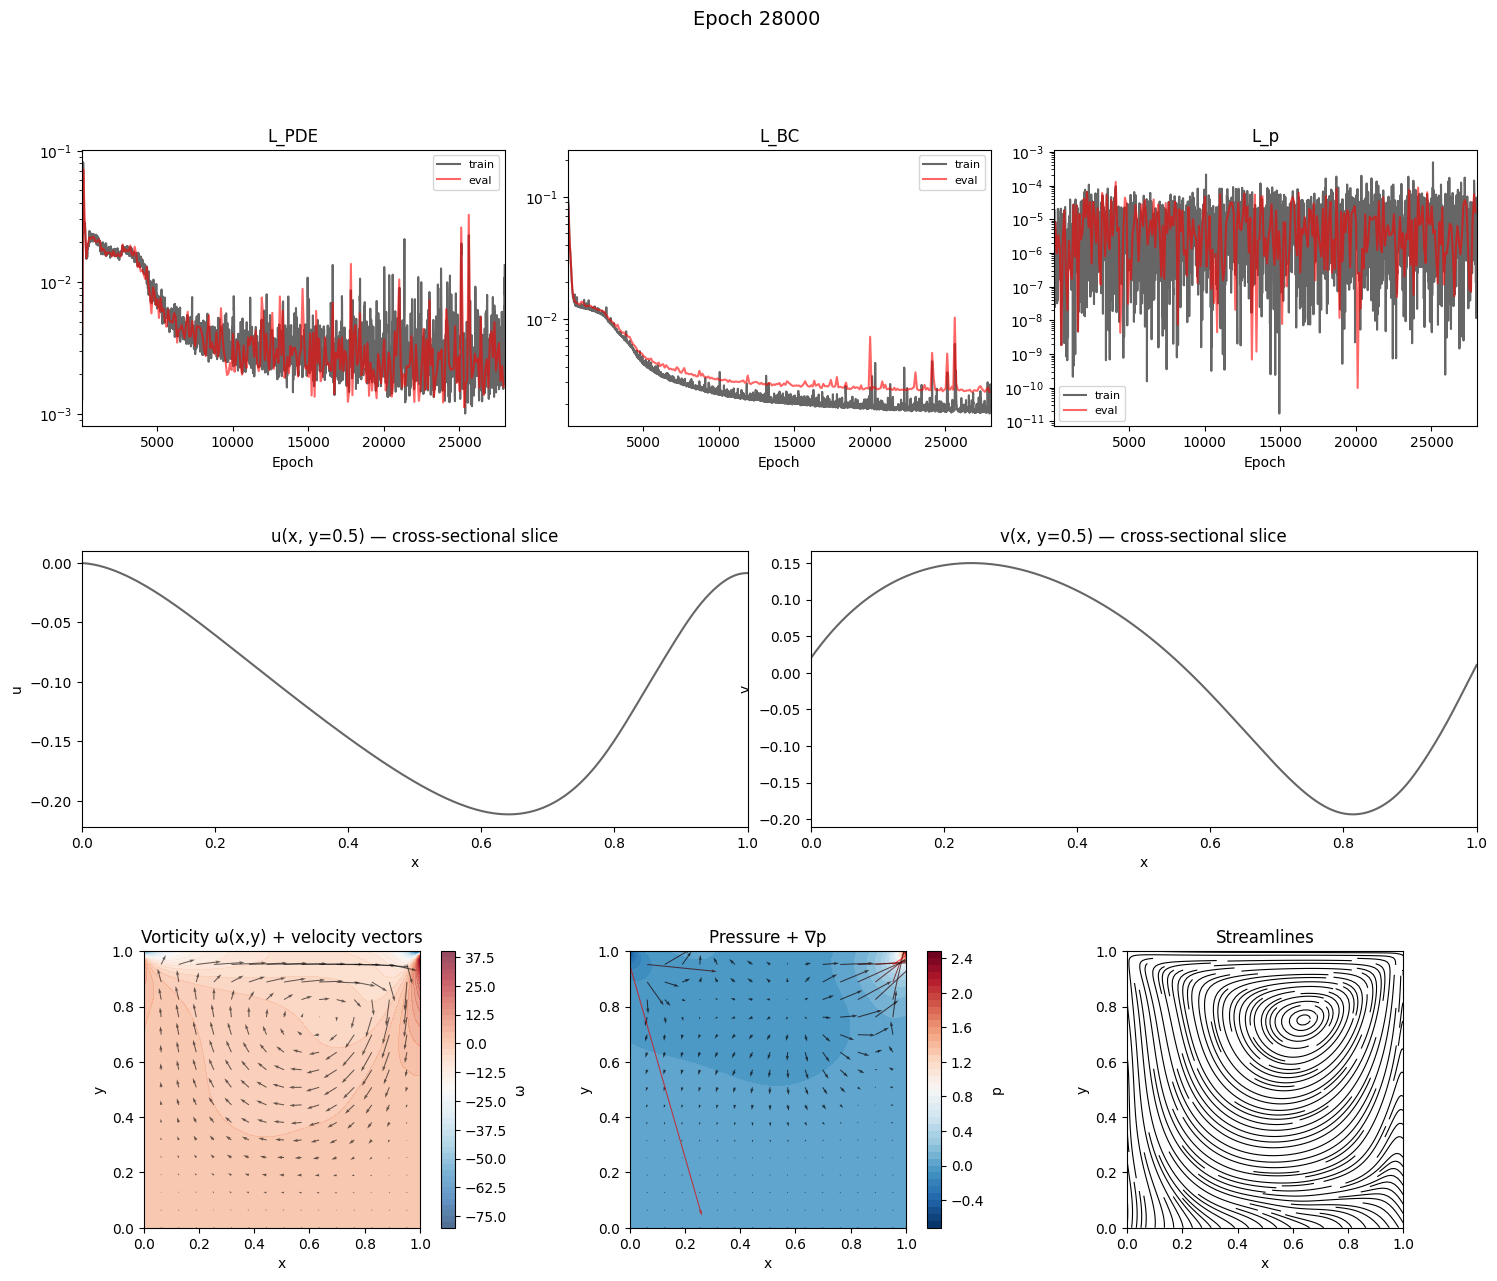

...............................

KeyboardInterrupt: 

In [21]:
t_train_start = time.perf_counter()

while epoch < num_epochs:
    epoch += 1
    t_step_start = time.perf_counter()

    opt.zero_grad()

    # Boundary condition loss
    u_p, v_p, _ = net(x_bc, y_bc)
    loss_bc = ((u_p - u_bc)**2 + (v_p - v_bc)**2).mean()

    # Resample collocation points each epoch
    x_f, y_f = make_collocation_points(N_f)

    # PDE residual loss
    r_x, r_y, r_c = ns_residual(net, x_f, y_f, nu)
    loss_pde = (r_x**2 + r_y**2 + r_c**2).mean()

    # Pressure gauge fix: pin p=0 at domain centre
    _, _, p_mid = net(torch.tensor([[0.5]]), torch.tensor([[0.5]]))
    loss_p = p_mid**2

    loss = 10 * loss_bc + loss_pde + 10 * loss_p
    loss.backward()
    opt.step()

    step_ms = (time.perf_counter() - t_step_start) * 1e3
    epochs_train.append(epoch)
    train_loss.append(loss.item())
    train_pde_loss.append(loss_pde.item())
    train_bc_loss.append(loss_bc.item())
    train_p_loss.append(loss_p.item())
    print('.' if epoch % 100 else (str(epoch)+'\n'), end='', flush=True)

    if epoch % 10 == 0:
        t_eval_start = time.perf_counter()
        l_pde, l_bc, l_p = eval_all_losses(net, nu, N_eval=N_eval_pde)
        eval_ms = (time.perf_counter() - t_eval_start) * 1e3
        epochs_eval.append(epoch)
        eval_pde_loss.append(l_pde)
        eval_bc_loss.append(l_bc)
        eval_p_loss.append(l_p)
        if epoch % 1000 == 0:
            visualize(net, epoch, {
                'epochs_train':   epochs_train,
                'train_pde_loss': train_pde_loss,
                'train_bc_loss':  train_bc_loss,
                'train_p_loss':   train_p_loss,
                'epochs_eval':    epochs_eval,
                'eval_pde_loss':  eval_pde_loss,
                'eval_bc_loss':   eval_bc_loss,
                'eval_p_loss':    eval_p_loss,
            })
        if epoch % log_every == 0:
            print(f"\nepoch {epoch:>6d} | L_bc {loss_bc.item():.3e} | L_pde {loss_pde.item():.3e} | L_p {loss_p.item():.3e} | eval L_pde {l_pde:.3e} | step {step_ms:.1f}ms")

print()
total_min = (time.perf_counter() - t_train_start) / 60
print(f"Training complete — {total_min:.1f} min  (epoch:{epoch})")

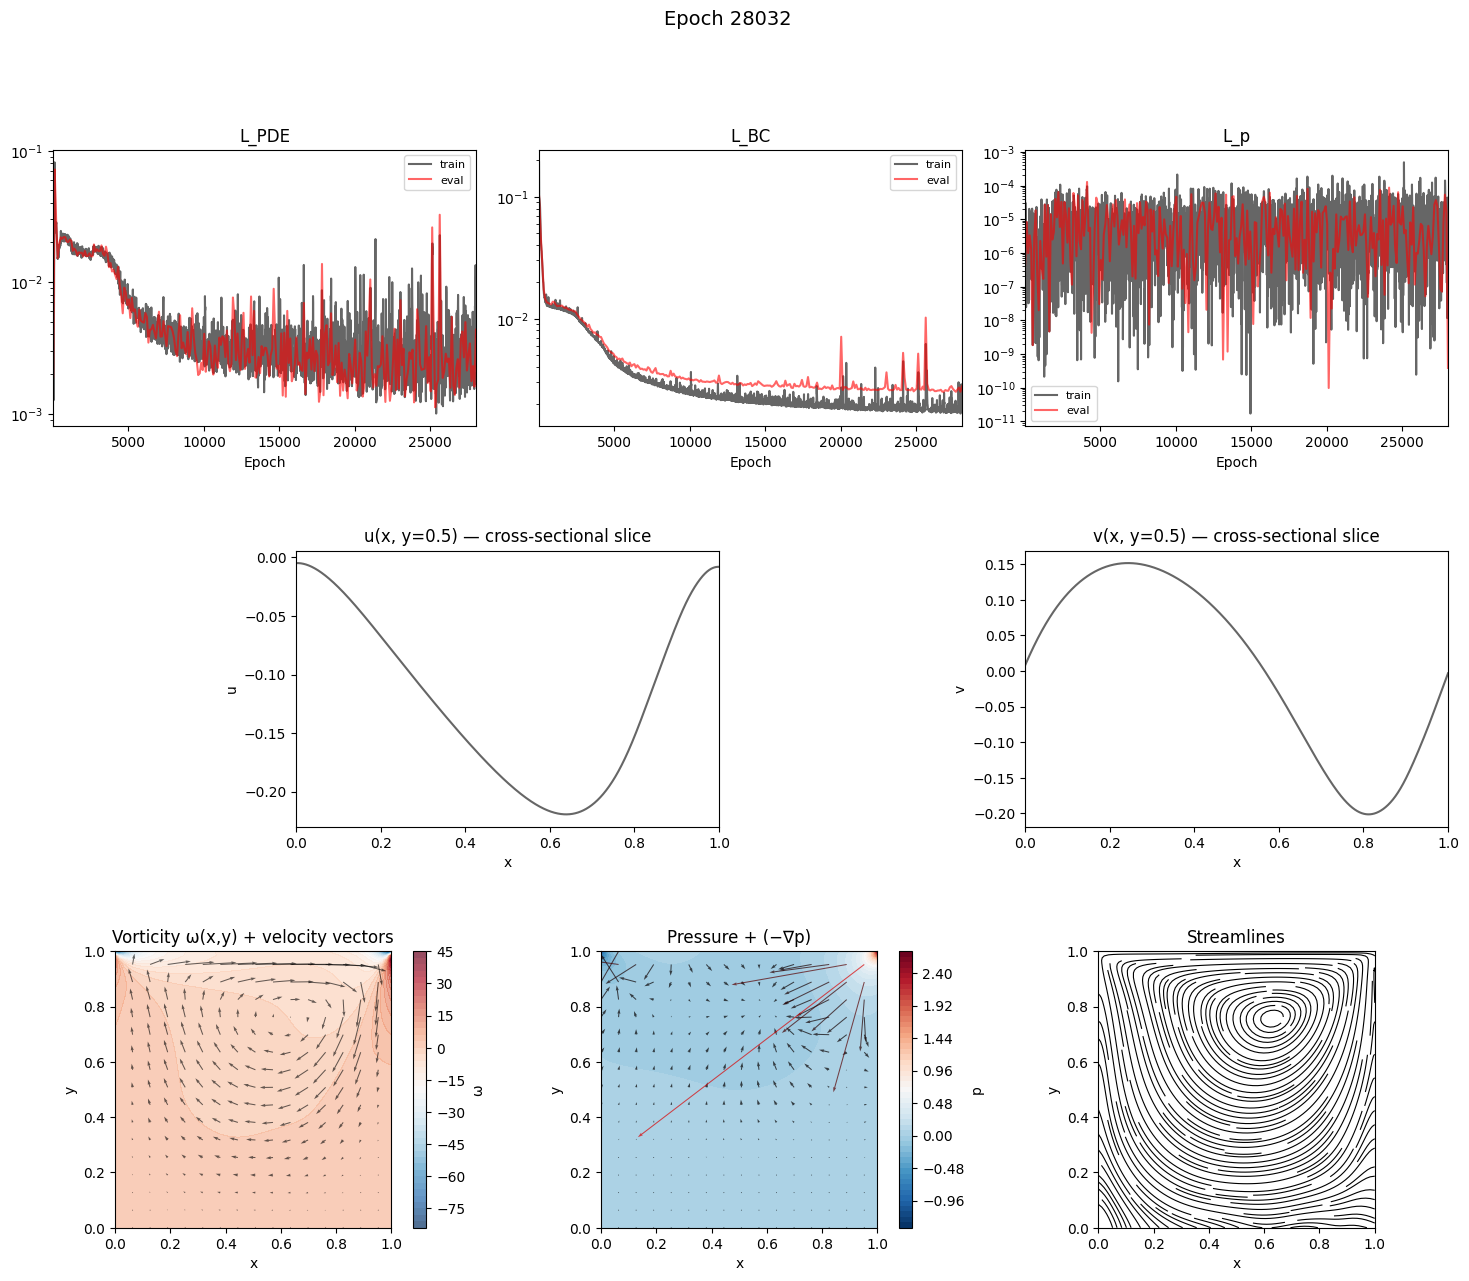

In [24]:
import importlib, pinn
importlib.reload(pinn)
from pinn import visualize

visualize(net, epoch, {
    'epochs_train':   epochs_train,
    'train_pde_loss': train_pde_loss,
    'train_bc_loss':  train_bc_loss,
    'train_p_loss':   train_p_loss,
    'epochs_eval':    epochs_eval,
    'eval_pde_loss':  eval_pde_loss,
    'eval_bc_loss':   eval_bc_loss,
    'eval_p_loss':    eval_p_loss,
})


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

s = 10  # downsample stride

axes[0].semilogy(epochs_train[::s], train_pde_loss[::s], c='k', alpha=0.6, label='train')
axes[0].semilogy(epochs_eval[::s],  eval_pde_loss[::s],  c='r', alpha=0.6, label='eval')
axes[0].set_title("L_PDE")
axes[0].legend()

axes[1].semilogy(epochs_train[::s], train_bc_loss[::s], c='k', alpha=0.6, label='train')
axes[1].semilogy(epochs_eval[::s],  eval_bc_loss[::s],  c='r', alpha=0.6, label='eval')
axes[1].set_title("L_BC")
axes[1].legend()

axes[2].semilogy(epochs_train[::s], train_p_loss[::s], c='k', alpha=0.6, label='train')
axes[2].semilogy(epochs_eval[::s],  eval_p_loss[::s],  c='r', alpha=0.6, label='eval')
axes[2].set_title("L_p")
axes[2].legend()

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.margins(x=0)

plt.suptitle("Train vs Eval Loss terms", fontsize=13)
plt.tight_layout()
plt.show()

## Inference

In [ ]:
x_q = torch.tensor([[0.5]])
y_q = torch.tensor([[0.8]])

with torch.no_grad():
    u_pred, v_pred, p_pred = net(x_q, y_q)

print(f"u = {u_pred.item():.4f}   (expect ~0.72 near lid — Ghia et al.)")
print(f"v = {v_pred.item():.4f}")
print(f"p = {p_pred.item():.4f}")

### Horizontal cross-section at y = 0.5

In [ ]:
N_section = 10_000
x_section = torch.linspace(0, 1, N_section).unsqueeze(1)
y_section  = torch.full((N_section, 1), 0.5)

with torch.no_grad():
    u_section, v_section, _ = net(x_section, y_section)

u_section = u_section.squeeze().numpy()
v_section = v_section.squeeze().numpy()
x_plot    = x_section.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_plot, u_section, c='k', alpha=0.6)
axes[0].set_xlabel("x")
axes[0].set_ylabel("u")
axes[0].set_title("u(x, y=0.5) — horizontal cross-section")
axes[0].margins(x=0)

axes[1].plot(x_plot, v_section, c='k', alpha=0.6)
axes[1].set_xlabel("x")
axes[1].set_ylabel("v")
axes[1].set_title("v(x, y=0.5) — horizontal cross-section")
axes[1].margins(x=0)

plt.tight_layout()
plt.show()

## Visualization

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

black_red = LinearSegmentedColormap.from_list("black_red", ["black", "red"])

step = 4  # quiver subsampling → 16×16 arrows on 64×64 grid
xs, ys, U, V, P = eval_flow_field(net, N=64)

dP_dx, dP_dy = np.gradient(P, xs, ys)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# Left: velocity quiver coloured by speed
speed = np.sqrt(U**2 + V**2)
q0 = axes[0].quiver(
    xs[::step], ys[::step],
    U[::step, ::step].T,
    V[::step, ::step].T,
    speed[::step, ::step].T.flatten(),
    cmap=black_red,
)
plt.colorbar(q0, ax=axes[0], label="|u|")
axes[0].set_title("Velocity field (u, v)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect("equal")

# Right: grad(p) quiver coloured by magnitude
mag = np.sqrt(dP_dx**2 + dP_dy**2)
q1 = axes[1].quiver(
    xs[::step], ys[::step],
    dP_dx[::step, ::step].T,
    dP_dy[::step, ::step].T,
    mag[::step, ::step].T.flatten(),
    cmap=black_red,
)
plt.colorbar(q1, ax=axes[1], label="|∇p|")
axes[1].set_title("Pressure gradient ∇p")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.streamplot(xs, ys, U.T, V.T, color='k', density=2, linewidth=0.8, arrowsize=0.8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_title("Streamlines")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()